In [62]:
import pandas as pd
from pathlib import Path
import numpy as np
import time
import os
import statsmodels
import seaborn as sns
import matplotlib.pyplot as plt
import glob
from scipy import stats
import scipy.stats as stats
from scipy.stats import ttest_rel
import pingouin as pg
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf

In [63]:
def coefplot_gap(results, multiple_models=False, fig_name=None):
    '''
    Creates a coefficient plot with confidence intervals.
   
    Parameters:
    results : statsmodels results object or DataFrame
        If multiple_models=False: statsmodels results object
        If multiple_models=True: DataFrame with columns: index, model, Coef., [0.025, P>|z|
    multiple_models : bool, default False
        Whether to create a plot for multiple models or single model
   
    Returns:
        matplotlib plot
    '''
    # Create/process dataframe based on input type
    if not multiple_models:
        coef_df = pd.DataFrame(results.summary().tables[1]).reset_index()
    else:
        coef_df = results.copy()
   
    # Drop unwanted rows
    coef_df = coef_df.loc[coef_df["index"].isin(['Group Var', 'Intercept']) == False]
   
    # Convert numeric columns to float
    coef_df['Coef.'] = coef_df['Coef.'].astype(float)
    coef_df['[0.025'] = coef_df['[0.025'].astype(float)
    coef_df['P>|z|'] = coef_df['P>|z|'].astype(float)
   
    # Calculate errors
    coef_df['errors'] = coef_df['Coef.'] - coef_df['[0.025']
   
    # Create significance indicators - make them consistent between both cases
    if multiple_models:
        coef_df['Significance'] = coef_df['P>|z|'].apply(
            lambda x: 'Significant' if x < 0.05 else 'Not Significant'
        )
    else:
        # Changed to match the multiple models case
        coef_df['Significance'] = coef_df['P>|z|'].apply(
            lambda x: 'Significant' if x < 0.05 else 'Not Significant'
        )
   
    # Clean up Treatment variable names
    for var_name in coef_df['index'].unique():
        if "Treatment" in var_name:
            if ":" in var_name:
                var1 = var_name.split("[",1)[1].split("]")[0]
                var2 = var_name.split("[", 2)[-1]
                new_var_name = var1 + ":" + var2
            else:
                new_var_name = var_name.split("[", 1)[1].split("]")[0]
            coef_df['index'] = coef_df['index'].replace(var_name, new_var_name)
   
    # Create plot
    fig, ax = plt.subplots(figsize=(18, 10))
   
    # Define consistent marker styles
    marker_styles = {'Significant': 'X', 'Not Significant': 'o'}
   

    if multiple_models:
        # Get models and calculate positions
        models = coef_df['model'].unique()
        variables = coef_df['index'].unique()
        n_models = len(models)
        space_between = 2.5
        model_spacing = 1.0
       
        # Create position mapping
        positions = {}
        # Sort variables by their average coefficient value (lowest to highest)
        var_means = coef_df.groupby('index')['Coef.'].mean().sort_values()
        sorted_vars = var_means.index
       
        for i, var in enumerate(sorted_vars):
            base_pos = i * (n_models + space_between)
            for j, model in enumerate(models):
                positions[(var, model)] = base_pos + (j * model_spacing)
       
        # Add plot positions
        coef_df['plot_position'] = coef_df.apply(
            lambda row: positions[(row['index'], row['model'])],
            axis=1
        )
       
        # Set up colors for multiple models
        model_palette = sns.color_palette("husl", n_colors=len(models))
        model_colors = dict(zip(models, model_palette))
       
        # Plot error bars
        for model in models:
            model_data = coef_df[coef_df['model'] == model]
            plt.errorbar(x=model_data['Coef.'],
                        y=model_data['plot_position'],
                        xerr=model_data['errors'],
                        color=model_colors[model],
                        capsize=3,
                        fmt='none',
                        alpha=0.7,
                        zorder=1)
       
        # Plot points
        g = sns.scatterplot(data=coef_df,
                           x='Coef.',
                           y='plot_position',
                           hue='model',
                           style='Significance',
                           markers=marker_styles,
                           palette=model_colors,
                           s=200,
                           zorder=3,
                           ax=ax)
       
        # Set y-ticks
        tick_positions = []
        for i, var in enumerate(sorted_vars):
            base_pos = i * (n_models + space_between)
            middle_pos = base_pos + ((n_models - 1) * model_spacing) / 2
            tick_positions.append(middle_pos)
       
        ax.set_yticks(tick_positions)
        ax.set_yticklabels(sorted_vars)
       
        # Create legends
        g.legend_.remove()
       
        # Model legend
        model_legend = ax.legend(
            title='Models',
            handles=[plt.Line2D([], [], marker='o', color=color, linestyle='None',
                               markersize=10, label=model)
                    for model, color in model_colors.items()],
            bbox_to_anchor=(1.02, 1),
            loc='upper left'
        )
       
        # Significance legend
        significance_handles = [
            plt.Line2D([], [], marker='X', color='gray', linestyle='None',
                      markersize=10, label='Significant'),
            plt.Line2D([], [], marker='o', color='gray', linestyle='None',
                      markersize=10, label='Not Significant')
        ]
       
        ax.add_artist(model_legend)
        ax.legend(handles=significance_handles,
                 title='Significance',
                 bbox_to_anchor=(1.02, 0.6),
                 loc='upper left')
       
    else:
        # Sort the dataframe by coefficient values (lowest to highest)
        coef_df = coef_df.sort_values(by='Coef.', ascending=False)
       
        # Single model plot
        palette = sns.color_palette("Set1")
        color_map = {'Significant': palette[0], 'Not Significant': palette[1]}
       
        # Error bars
        for idx, row in coef_df.iterrows():
            error_color = color_map[row['Significance']]
            plt.errorbar(x=row['Coef.'],
                        y=row['index'],
                        xerr=row['errors'],
                        color=error_color,
                        capsize=3,
                        fmt='none',
                        zorder=1)
       
        # Scatter plot with consistent markers
        g = sns.scatterplot(y='index',
                           x='Coef.',
                           style='Significance',
                           hue='Significance',
                           markers=marker_styles,
                           palette=color_map,
                           s=200,
                           data=coef_df,
                           zorder=3,
                           ax=ax)
   
    # Common plot elements
    ax.axvline(x=0, linestyle='--', color='red', linewidth=1)
   
    # Set title & labels
    title = 'Coefficients Across Models w/ 95% Confidence Intervals' if multiple_models else 'Coefficients of Features w/ 95% Confidence Intervals'
    plt.title(title, fontsize=30)
    ax.set_ylabel('Variables' if multiple_models else 'Coefficients', fontsize=22)
    ax.set_xlabel('Coefficient Value' if multiple_models else '', fontsize=22)
   
    # Set x-axis limits
    ax.set_xlim(coef_df['Coef.'].min() - max(coef_df['errors']),
                coef_df['Coef.'].max() + max(coef_df['errors']))
   
    plt.tight_layout()

    plt.show()
    return plt.show()

In [64]:
def check_homoscedasticity(model, data, show_text= True, co_vars = None):
    # Check for multicollinearity
    vif = pd.DataFrame()
    vif["variables"] = model.model.exog_names
    # Drop the intercept
    vif["VIF"] = [variance_inflation_factor(model.model.exog, i) for i in range(model.model.exog.shape[1])]
    vif = vif.loc[vif["variables"] != "Intercept"]
       
    homoscedasticity_per_variable = []
    #levene_test = stats.levene(model.fittedvalues, model.resid)

        # Get residuals
    residuals = model.resid
    fitted = model.fittedvalues
   
    # Levene's test for homoscedasticity
    groups = pd.qcut(fitted, q=4)  # Create groups based on fitted values
    levene = stats.levene(*[group_residuals for name, group_residuals in residuals.groupby(groups)])


    if levene[1] < 0.05:
        print("Residuals are not homoscedastic", levene)
    # Do other tests to check for homoscedasticity such as bartlett or White test as well as normality test
    bartlett_test = stats.bartlett(model.fittedvalues, model.resid)
    white_test = statsmodels.stats.diagnostic.het_white(model.resid, model.model.exog)
    shapiro_test = stats.shapiro(model.resid)

    if show_text:
        print(f'Bartlett’s test p-value: {bartlett_test[1]}')
    # White test
        print(f'White test p-value: {white_test[1]}')  
        print(f'Levene’s test p-value for the whole model: {levene[1]}')
    homoscedasticity_per_variable.append({"levene_test_all": levene[1]})
    homoscedasticity_per_variable.append({"white_test": white_test[1]})
    homoscedasticity_per_variable.append({"bartlett_test": bartlett_test[1]})
    homoscedasticity_per_variable.append({"shapiro_test": shapiro_test[1]})
    homoscedasticity_per_variable.append({"multicollinearity": vif["VIF"].max()})              

    for variable in co_vars:
        if variable not in data.columns:
            continue
        residuals = model.resid
        group1 = residuals[data[variable] == data[variable].unique()[0]]
        group2 = residuals[data[variable] == data[variable].unique()[1]]

        stat, p_value = stats.levene(group1, group2)
        if show_text:
            print(f'Levene’s test p-value for variable {variable}: {p_value}')
        homoscedasticity_per_variable.append({variable: p_value.round(5)})
    homoscedasticity_df = pd.DataFrame(homoscedasticity_per_variable)
    homoscedasticity_df = pd.DataFrame([homoscedasticity_df.max()])

    print("Homoscedasticiyy checked")
    return homoscedasticity_df


def check_assumptions(model, data, show_plots=True, show_text= True, covariates = None):
    # Check for normality of residuals
    if show_plots:
        # Check for normality of residuals
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
       
        # Residuals vs Fitted
        sns.scatterplot(
            x=model.fittedvalues,
            y=model.resid,
            ax=axes[0,0]
        )
        axes[0,0].axhline(y=0, color='r', linestyle='--')
        axes[0,0].set_xlabel('Fitted values')
        axes[0,0].set_ylabel('Residuals')
        axes[0,0].set_title('Residuals vs Fitted')
       
        # QQ Plot
        stats.probplot(model.resid, dist="norm", plot=axes[0,1])
        axes[0,1].set_title('Normal Q-Q Plot')
       
        sns.scatterplot(
            x=model.fittedvalues,
            y=model.resid,
            ax=axes[1,0]
        )
        axes[1,0].set_xlabel('Fitted values')
        axes[1,0].set_ylabel('Residuals')
        axes[1,0].set_title('Homoscedasticity')
       
        # Residuals histogram
        sns.histplot(model.resid, kde=True, ax=axes[1,1])
        axes[1,1].set_title('Residuals Distribution')
       
        plt.tight_layout()
        plt.show()
    if show_text:
        shapiro_test = stats.shapiro(model.resid)
        print(f'Shapiro-Wilk test p-value: {shapiro_test[1]}')

    # Test for homoscedasticity using levens test
    check_homoscedasticity(model, data,show_text= True, co_vars = covariates)

       
    return "Assumptions checked"

def stage_model(model):

    coef_df = pd.DataFrame(model.summary().tables[1]).reset_index()
    if "Coef." not in coef_df.columns:
            # Make the first row the columns
            coef_df.columns = coef_df.iloc[0].astype(str)
            # Drop the first row
            coef_df = coef_df[1:]
            # Drop the first column
            coef_df = coef_df.drop(columns=["0"])
            # Rename the columns
            coef_df.rename(columns={"": "index", "coef":'Coef.','std err':'Std.Err.', "t":"stat","P>|t|":"P>|z|"}, inplace=True)
            coef_df['Coef.']=coef_df['Coef.'].astype(str)
            coef_df['Std.Err.']=coef_df['Std.Err.'].astype(str)
            coef_df['stat']=coef_df['stat'].astype(str)
            coef_df['P>|z|']=coef_df['P>|z|'].astype(str)
            coef_df['[0.025']=coef_df['[0.025'].astype(str)
            coef_df['0.975]']=coef_df['0.975]'].astype(str)
            coef_df["index"]= coef_df["index"].astype(str)


    else:
        coef_df.rename(columns={"z":"stat", "P>|z|":"P>|z|"}, inplace=True)
           
           
    # Drop unwanted rows where z values are ''
    coef_df = coef_df.loc[coef_df.stat != ''].copy()    

    # Drop the intercept row as well
    coef_df = coef_df.loc[coef_df["index"].isin(['Intercept']) == False]

    # Convert numeric columns to float
    coef_df['Coef.'] = coef_df['Coef.'].astype(float)
    coef_df['[0.025'] = coef_df['[0.025'].astype(float)
    coef_df['P>|z|']= coef_df['P>|z|'].astype(float)
   
    # Calculate errors
    coef_df['errors'] = coef_df['Coef.'] - coef_df['[0.025']

    return coef_df

In [220]:
file_path = '/Users/audrey-annebeaudry/Desktop/Final_folder_VS/VS_results.csv'

In [233]:
vs_eeg = pd.read_csv(file_path)
vs_eeg

,subject,diagnosis,set_size,N1_amp,N1_lat,N1_chan,P3b_amp,P3b_lat,P3b_chan,alpha_power,gamma_power
0,0171M1,control,5,-2.693449e-06,0.095,E59,0.000003,0.355,E92,5.320556e-11,4.357310e-11
1,0171M1,control,9,-1.320499e-06,0.131,E92,0.000003,0.349,E87,4.504331e-11,4.186868e-11
2,0171M1,control,13,-9.898812e-07,0.134,E92,0.000005,0.448,E59,4.939756e-11,4.566363e-11
3,0131P,asd,5,-4.085812e-06,0.090,E92,0.000032,0.323,E59,2.201703e-09,7.876936e-11
4,0131P,asd,9,-8.019594e-06,0.080,E92,0.000028,0.317,E59,1.502232e-09,7.606831e-11
...,...,...,...,...,...,...,...,...,...,...,...
283,0162P,asd,9,-6.188868e-06,0.130,E53,0.000014,0.300,E92,1.482893e-09,6.939865e-11
284,0162P,asd,13,-6.349377e-06,0.089,E59,0.000010,0.426,E92,1.374909e-09,5.661023e-11
285,1052S1,control,5,-2.810581e-06,0.130,E53,0.000040,0.309,E59,2.653518e-09,1.135784e-10
286,1052S1,control,9,-2.087018e-05,0.080,E59,0.000035,0.403,E59,1.709421e-09,1.631741e-10


In [234]:
# Number of subjects total:
unique_subjects = vs_eeg['subject'].nunique()
unique_subjects

96

In [235]:
# Load demographic data

demo_df = pd.read_csv("/Users/audrey-annebeaudry/Desktop/Final_folder_VS/q1k_attempted_demographic_ouputs_2025_07_12.csv")

In [236]:
demo_df['bids_id'] = demo_df['bids_id'].str.replace('sub-', '', regex=False)

In [237]:
# keep only the subjects that are in the vs_eeg 
demo_df = demo_df[demo_df['bids_id'].isin(vs_eeg['subject'])]

In [238]:
# Keep important columns
demo_df = demo_df[["eeg_age", "group", "site", "eeg_sex", "asd",  "bids_id", "adhd"]]

In [239]:
demo_df

,eeg_age,group,site,eeg_sex,asd,bids_id,adhd
3,36.206082,proband,hsj,1,0.0,0104P,1.0
26,40.162244,mother,hsj,1,NaN,0129M1,NaN
27,8.432640,proband,hsj,1,0.0,0131P,1.0
28,13.582757,sibling,hsj,1,NaN,0131S1,NaN
32,32.501694,mother,hsj,1,0.0,0134M1,0.0
...,...,...,...,...,...,...,...
224,22.782238,sibling,hsj,1,0.0,1147S2,0.0
337,40.611375,proband,hsj,1,0.0,0062P,0.0
340,12.216541,sibling,hsj,2,1.0,0064S1,1.0
341,38.076073,mother,hsj,1,NaN,0064M1,NaN


In [240]:
demo_df["asd"] = demo_df["asd"].fillna("Unknown")

In [241]:
# Create column for age group
demo_df['age_group'] = pd.cut(demo_df['eeg_age'], bins=[0, 18, 100], labels=['child', 'adult'])
unknown_asd = demo_df[demo_df['asd'] == 'Unknown']  # Filter rows where 'asd' is 'unknown'
demo_df = demo_df[demo_df['asd'] != 'Unknown']

In [242]:
demo_df

,eeg_age,group,site,eeg_sex,asd,bids_id,adhd,age_group
3,36.206082,proband,hsj,1,0.0,0104P,1.0,adult
27,8.432640,proband,hsj,1,0.0,0131P,1.0,child
32,32.501694,mother,hsj,1,0.0,0134M1,0.0,adult
33,34.615358,father,hsj,2,0.0,0134F1,1.0,adult
34,32.608472,proband,hsj,1,1.0,0146P,1.0,adult
46,12.996845,proband,hsj,2,1.0,0162P,1.0,child
47,12.996845,sibling,hsj,1,0.0,0162S1,0.0,child
49,12.309516,proband,mni,2,1.0,0171P,0.0,child
50,40.208788,mother,mni,1,0.0,0171M1,0.0,adult
52,40.208788,father,mni,2,0.0,0171F1,0.0,adult


In [243]:
def assign_diagnosis_group(row):
    if row['asd'] == 1:  # If ASD is 1, assign 'asd' regardless of ADHD
        return 'asd'
    elif row['adhd'] == 1:  # If ADHD is 1, assign 'adhd'
        return 'adhd'
    else:
        return 'control'  # Default to control if neither ASD nor ADHD is 1

# Apply the function to each row to create the 'diagnosis_group' column
demo_df.loc[:, 'diagnosis_group'] = demo_df.apply(assign_diagnosis_group, axis=1)

/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_42522/1970945888.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_df.loc[:, 'diagnosis_group'] = demo_df.apply(assign_diagnosis_group, axis=1)


In [244]:
demo_df

,eeg_age,group,site,eeg_sex,asd,bids_id,adhd,age_group,diagnosis_group
3,36.206082,proband,hsj,1,0.0,0104P,1.0,adult,adhd
27,8.432640,proband,hsj,1,0.0,0131P,1.0,child,adhd
32,32.501694,mother,hsj,1,0.0,0134M1,0.0,adult,control
33,34.615358,father,hsj,2,0.0,0134F1,1.0,adult,adhd
34,32.608472,proband,hsj,1,1.0,0146P,1.0,adult,asd
46,12.996845,proband,hsj,2,1.0,0162P,1.0,child,asd
47,12.996845,sibling,hsj,1,0.0,0162S1,0.0,child,control
49,12.309516,proband,mni,2,1.0,0171P,0.0,child,asd
50,40.208788,mother,mni,1,0.0,0171M1,0.0,adult,control
52,40.208788,father,mni,2,0.0,0171F1,0.0,adult,control


In [245]:
for subject in vs_eeg.subject.unique():
    if subject in demo_df.bids_id.unique():
        continue
    else: 
        print (f"Flag '{subject}'") #STILL NEED TO ADD THE CONTROL DOCUMENTATION!

Flag '1009M1'
Flag '1052F1'
Flag '1121S1'
Flag '1037F1'
Flag '1080M1'
Flag '0162M1'
Flag '1028S1'
Flag '1083S1'
Flag '1026M1'
Flag '1009S1'
Flag '0131S1'
Flag '0265M1'
Flag '1118F1'
Flag '1042F1'
Flag '0218M1'
Flag '1112M1'
Flag '1028S2'
Flag '1033S1'
Flag '1045S1'
Flag '1006M1'
Flag '0093O1'
Flag '1106M1'
Flag '0216M1'
Flag '1052M1'
Flag '1024M1'
Flag '1067S1'
Flag '1078F1'
Flag '0064M1'
Flag '1134S1'
Flag '1121F1'
Flag '1042M1'
Flag '1061S3'
Flag '1073M1'
Flag '1033M1'
Flag '1057F1'
Flag '0129M1'
Flag '1061F1'
Flag '0248M1'
Flag '1052S1'


In [246]:
# Assuming demo_df is already defined as the demographic dataframe

# Summarize data by diagnosis groups
summary_table = demo_df.groupby("diagnosis_group").agg(
    n=("diagnosis_group", "count"),
    male=("eeg_sex", lambda x: (x == "male").sum()),
    female=("eeg_sex", lambda x: (x == "female").sum()),
    mean_age=("eeg_age", "mean"),
    std_age=("eeg_age", "std"),
    hsj=("site", lambda x: (x == "hsj").sum()),
    mni=("site", lambda x: (x == "mni").sum()),
    adults=("age_group", lambda x: (x == "adult").sum()),
    children=("age_group", lambda x: (x == "child").sum()),
).reset_index()

# Add combined row for all participants
all_participants = {
    "diagnosis_group": "combined",
    "n": summary_table["n"].sum(),
    "male": summary_table["male"].sum(),
    "female": summary_table["female"].sum(),
    "mean_age": demo_df["eeg_age"].mean(),
    "std_age": demo_df["eeg_age"].std(),
    "hsj": summary_table["hsj"].sum(),
    "mni": summary_table["mni"].sum(),
    "adults": summary_table["adults"].sum(),
    "children": summary_table["children"].sum(),
}

summary_table = pd.concat(
    [pd.DataFrame([all_participants]), summary_table], ignore_index=True
)

# Create combined and percentage columns
summary_table["sex (M:F)"] = summary_table["male"].astype(str) + ":" + summary_table["female"].astype(str)
summary_table["sex % (M:F)"] = (
    (summary_table["male"] / summary_table["n"] * 100).round(2).astype(str)
    + ":"
    + (summary_table["female"] / summary_table["n"] * 100).round(2).astype(str)
)

summary_table["site (HSJ:MNI)"] = summary_table["hsj"].astype(str) + ":" + summary_table["mni"].astype(str)
summary_table["site % (HSJ:MNI)"] = (
    (summary_table["hsj"] / summary_table["n"] * 100).round(2).astype(str)
    + ":"
    + (summary_table["mni"] / summary_table["n"] * 100).round(2).astype(str)
)

# Drop intermediate columns to keep the table clean
summary_table.drop(columns=["male", "female", "hsj", "mni"], inplace=True)

# Rename columns for better clarity
summary_table.rename(
    columns={
        "diagnosis_group": "Diagnosis Group",
        "n": "Total Participants",
        "mean_age": "Mean Age",
        "std_age": "Age SD",
        "adults": "Adults",
        "children": "Children",
    },
    inplace=True,
)
summary_table=summary_table.round(2)

In [247]:
summary_table

,Diagnosis Group,Total Participants,Mean Age,Age SD,Adults,Children,sex (M:F),sex % (M:F),site (HSJ:MNI),site % (HSJ:MNI)
0,combined,57,25.77,16.15,28,29,0:0,0.0:0.0,29:28,50.88:49.12
1,adhd,10,20.11,13.77,3,7,0:0,0.0:0.0,9:1,90.0:10.0
2,asd,20,16.01,8.51,4,16,0:0,0.0:0.0,11:9,55.0:45.0
3,control,27,35.09,16.35,21,6,0:0,0.0:0.0,9:18,33.33:66.67


In [248]:
print(demo_df.group.value_counts())

group
proband    26
mother     14
sibling     9
father      8
Name: count, dtype: int64


In [249]:
vs_eeg["subject"] = vs_eeg["subject"].astype(str)
demo_df["bids_id"] = demo_df["bids_id"].astype(str)
vs_eeg["subject"] = vs_eeg["subject"].str.strip()
demo_df["bids_id"] = demo_df["bids_id"].str.strip()
demo_df["diagnosis_group"] = demo_df["diagnosis_group"].astype(str).replace("nan", np.nan)

/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_42522/2762361506.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_df["bids_id"] = demo_df["bids_id"].astype(str)
/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_42522/2762361506.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demo_df["bids_id"] = demo_df["bids_id"].str.strip()
/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_42522/2762361506.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sl

In [250]:
demo_df

,eeg_age,group,site,eeg_sex,asd,bids_id,adhd,age_group,diagnosis_group
3,36.206082,proband,hsj,1,0.0,0104P,1.0,adult,adhd
27,8.432640,proband,hsj,1,0.0,0131P,1.0,child,adhd
32,32.501694,mother,hsj,1,0.0,0134M1,0.0,adult,control
33,34.615358,father,hsj,2,0.0,0134F1,1.0,adult,adhd
34,32.608472,proband,hsj,1,1.0,0146P,1.0,adult,asd
46,12.996845,proband,hsj,2,1.0,0162P,1.0,child,asd
47,12.996845,sibling,hsj,1,0.0,0162S1,0.0,child,control
49,12.309516,proband,mni,2,1.0,0171P,0.0,child,asd
50,40.208788,mother,mni,1,0.0,0171M1,0.0,adult,control
52,40.208788,father,mni,2,0.0,0171F1,0.0,adult,control


In [251]:
## Merge the go_df and demo_df
demo_df = demo_df.rename(columns = {'bids_id' : 'subject'})
vs_eeg = pd.merge(vs_eeg, demo_df, on="subject", how="inner")
#print(df["asd"].unique())

In [252]:
vs_eeg

,subject,diagnosis,set_size,N1_amp,N1_lat,N1_chan,P3b_amp,P3b_lat,P3b_chan,alpha_power,gamma_power,eeg_age,group,site,eeg_sex,asd,adhd,age_group,diagnosis_group
0,0171M1,control,5,-2.693449e-06,0.095,E59,0.000003,0.355,E92,5.320556e-11,4.357310e-11,40.208788,mother,mni,1,0.0,0.0,adult,control
1,0171M1,control,9,-1.320499e-06,0.131,E92,0.000003,0.349,E87,4.504331e-11,4.186868e-11,40.208788,mother,mni,1,0.0,0.0,adult,control
2,0171M1,control,13,-9.898812e-07,0.134,E92,0.000005,0.448,E59,4.939756e-11,4.566363e-11,40.208788,mother,mni,1,0.0,0.0,adult,control
3,0131P,asd,5,-4.085812e-06,0.090,E92,0.000032,0.323,E59,2.201703e-09,7.876936e-11,8.432640,proband,hsj,1,0.0,1.0,child,adhd
4,0131P,asd,9,-8.019594e-06,0.080,E92,0.000028,0.317,E59,1.502232e-09,7.606831e-11,8.432640,proband,hsj,1,0.0,1.0,child,adhd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,0179P,asd,9,-7.303316e-06,0.137,E59,0.000009,0.324,E92,5.129513e-10,6.021700e-11,14.976351,proband,mni,1,1.0,1.0,child,asd
167,0179P,asd,13,-2.732904e-06,0.083,E87,0.000011,0.300,E92,5.970352e-10,5.429622e-11,14.976351,proband,mni,1,1.0,1.0,child,asd
168,0162P,asd,5,-6.216746e-06,0.085,E59,0.000013,0.466,E92,1.304796e-09,6.666229e-11,12.996845,proband,hsj,2,1.0,1.0,child,asd
169,0162P,asd,9,-6.188868e-06,0.130,E53,0.000014,0.300,E92,1.482893e-09,6.939865e-11,12.996845,proband,hsj,2,1.0,1.0,child,asd


In [253]:
def remove_outliers_iqr(df, columns):
    original_len = len(df)
    df_clean = df.copy()
    
    print("=== Outlier Removal Summary ===")
    
    for col in columns:
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        after = len(df_clean)
        removed = before - after
        print(f"{col}: removed {removed} rows")

    total_removed = original_len - len(df_clean)
    print(f"\nTotal rows removed: {total_removed}")
    print(f" Remaining rows: {len(df_clean)} of original {original_len}")
    
    return df_clean

# Define columns for each section
section_1_cols = ['alpha_power', 'gamma_power']
section_2_cols = ['P3b_amp', 'N1_amp']
section_3_cols = ['P3b_lat', 'N1_lat']

# Run outlier removal
vs_eeg_clean = remove_outliers_iqr(vs_eeg, section_1_cols + section_2_cols + section_3_cols)
vs_eeg_clean

=== Outlier Removal Summary ===
alpha_power: removed 6 rows
gamma_power: removed 9 rows
P3b_amp: removed 7 rows
N1_amp: removed 5 rows
P3b_lat: removed 0 rows
N1_lat: removed 0 rows

Total rows removed: 27
 Remaining rows: 144 of original 171


,subject,diagnosis,set_size,N1_amp,N1_lat,N1_chan,P3b_amp,P3b_lat,P3b_chan,alpha_power,gamma_power,eeg_age,group,site,eeg_sex,asd,adhd,age_group,diagnosis_group
0,0171M1,control,5,-2.693449e-06,0.095,E59,0.000003,0.355,E92,5.320556e-11,4.357310e-11,40.208788,mother,mni,1,0.0,0.0,adult,control
1,0171M1,control,9,-1.320499e-06,0.131,E92,0.000003,0.349,E87,4.504331e-11,4.186868e-11,40.208788,mother,mni,1,0.0,0.0,adult,control
2,0171M1,control,13,-9.898812e-07,0.134,E92,0.000005,0.448,E59,4.939756e-11,4.566363e-11,40.208788,mother,mni,1,0.0,0.0,adult,control
4,0131P,asd,9,-8.019594e-06,0.080,E92,0.000028,0.317,E59,1.502232e-09,7.606831e-11,8.432640,proband,hsj,1,0.0,1.0,child,adhd
5,0131P,asd,13,-2.589121e-06,0.080,E92,0.000019,0.319,E59,1.957669e-09,7.772006e-11,8.432640,proband,hsj,1,0.0,1.0,child,adhd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,0179P,asd,9,-7.303316e-06,0.137,E59,0.000009,0.324,E92,5.129513e-10,6.021700e-11,14.976351,proband,mni,1,1.0,1.0,child,asd
167,0179P,asd,13,-2.732904e-06,0.083,E87,0.000011,0.300,E92,5.970352e-10,5.429622e-11,14.976351,proband,mni,1,1.0,1.0,child,asd
168,0162P,asd,5,-6.216746e-06,0.085,E59,0.000013,0.466,E92,1.304796e-09,6.666229e-11,12.996845,proband,hsj,2,1.0,1.0,child,asd
169,0162P,asd,9,-6.188868e-06,0.130,E53,0.000014,0.300,E92,1.482893e-09,6.939865e-11,12.996845,proband,hsj,2,1.0,1.0,child,asd


In [254]:
# Number of subjects after outlier removal:
unique_subjects = vs_eeg_clean['subject'].nunique()
unique_subjects

53

In [256]:
# Find subjects that were completely removed
removed_subj = set(vs_eeg['subject'].unique()) - set(vs_eeg_clean['subject'].unique())

removed_diag = vs_eeg.loc[vs_eeg['subject'].isin(removed_subj), ['subject', 'diagnosis']].drop_duplicates()
removed_diag

,subject,diagnosis
15,0068S1,control
24,0200S1,control
42,0171P,asd
63,0275P,asd


In [261]:
vs_eeg_clean

,subject,diagnosis,set_size,N1_amp,N1_lat,N1_chan,P3b_amp,P3b_lat,P3b_chan,alpha_power,gamma_power,eeg_age,group,site,eeg_sex,asd,adhd,age_group,diagnosis_group
0,0171M1,control,5,-2.693449e-06,0.095,E59,0.000003,0.355,E92,5.320556e-11,4.357310e-11,40.208788,mother,mni,1,0.0,0.0,adult,control
1,0171M1,control,9,-1.320499e-06,0.131,E92,0.000003,0.349,E87,4.504331e-11,4.186868e-11,40.208788,mother,mni,1,0.0,0.0,adult,control
2,0171M1,control,13,-9.898812e-07,0.134,E92,0.000005,0.448,E59,4.939756e-11,4.566363e-11,40.208788,mother,mni,1,0.0,0.0,adult,control
4,0131P,asd,9,-8.019594e-06,0.080,E92,0.000028,0.317,E59,1.502232e-09,7.606831e-11,8.432640,proband,hsj,1,0.0,1.0,child,adhd
5,0131P,asd,13,-2.589121e-06,0.080,E92,0.000019,0.319,E59,1.957669e-09,7.772006e-11,8.432640,proband,hsj,1,0.0,1.0,child,adhd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,0179P,asd,9,-7.303316e-06,0.137,E59,0.000009,0.324,E92,5.129513e-10,6.021700e-11,14.976351,proband,mni,1,1.0,1.0,child,asd
167,0179P,asd,13,-2.732904e-06,0.083,E87,0.000011,0.300,E92,5.970352e-10,5.429622e-11,14.976351,proband,mni,1,1.0,1.0,child,asd
168,0162P,asd,5,-6.216746e-06,0.085,E59,0.000013,0.466,E92,1.304796e-09,6.666229e-11,12.996845,proband,hsj,2,1.0,1.0,child,asd
169,0162P,asd,9,-6.188868e-06,0.130,E53,0.000014,0.300,E92,1.482893e-09,6.939865e-11,12.996845,proband,hsj,2,1.0,1.0,child,asd


In [262]:
vs_eeg = vs_eeg_clean

# Analysis to look at condition comparison

In [263]:
vs_eeg.columns
vs_eeg['set_size'].unique()
vs_eeg[['alpha_power', 'gamma_power']].describe()

,alpha_power,gamma_power
count,1.440000e+02,1.440000e+02
mean,8.494432e-10,6.149418e-11
std,8.118115e-10,2.963819e-11
min,4.504331e-11,1.554973e-11
25%,2.319383e-10,4.010236e-11
50%,4.878592e-10,5.655961e-11
75%,1.308610e-09,7.574233e-11
max,3.243293e-09,1.451881e-10


In [264]:
vs_eeg['alpha_power'] =  np.log(vs_eeg['alpha_power'])
vs_eeg['gamma_power'] =  np.log(vs_eeg['gamma_power'])
vs_eeg['N1_amp'] = np.log(np.abs(vs_eeg['N1_amp']))#log of a negative = NaN (should we make them positive value) = do the absolute value
vs_eeg['P3b_amp'] =  np.log(vs_eeg['P3b_amp']) 

In [265]:
vs_eeg

,subject,diagnosis,set_size,N1_amp,N1_lat,N1_chan,P3b_amp,P3b_lat,P3b_chan,alpha_power,gamma_power,eeg_age,group,site,eeg_sex,asd,adhd,age_group,diagnosis_group
0,0171M1,control,5,-12.824688,0.095,E59,-12.726260,0.355,E92,-23.656858,-23.856581,40.208788,mother,mni,1,0.0,0.0,adult,control
1,0171M1,control,9,-13.537501,0.131,E92,-12.862242,0.349,E87,-23.823397,-23.896483,40.208788,mother,mni,1,0.0,0.0,adult,control
2,0171M1,control,13,-13.825681,0.134,E92,-12.189099,0.448,E59,-23.731120,-23.809719,40.208788,mother,mni,1,0.0,0.0,adult,control
4,0131P,asd,9,-11.733623,0.080,E92,-10.496700,0.317,E59,-20.316314,-23.299389,8.432640,proband,hsj,1,0.0,1.0,child,adhd
5,0131P,asd,13,-12.864192,0.080,E92,-10.895524,0.319,E59,-20.051512,-23.277908,8.432640,proband,hsj,1,0.0,1.0,child,adhd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,0179P,asd,9,-11.827182,0.137,E59,-11.617513,0.324,E92,-21.390840,-23.533066,14.976351,proband,mni,1,1.0,1.0,child,asd
167,0179P,asd,13,-12.810146,0.083,E87,-11.414546,0.300,E92,-21.239045,-23.636567,14.976351,proband,mni,1,1.0,1.0,child,asd
168,0162P,asd,5,-11.988264,0.085,E59,-11.259732,0.466,E92,-20.457219,-23.431382,12.996845,proband,hsj,2,1.0,1.0,child,asd
169,0162P,asd,9,-11.992758,0.130,E53,-11.153373,0.300,E92,-20.329271,-23.391154,12.996845,proband,hsj,2,1.0,1.0,child,asd


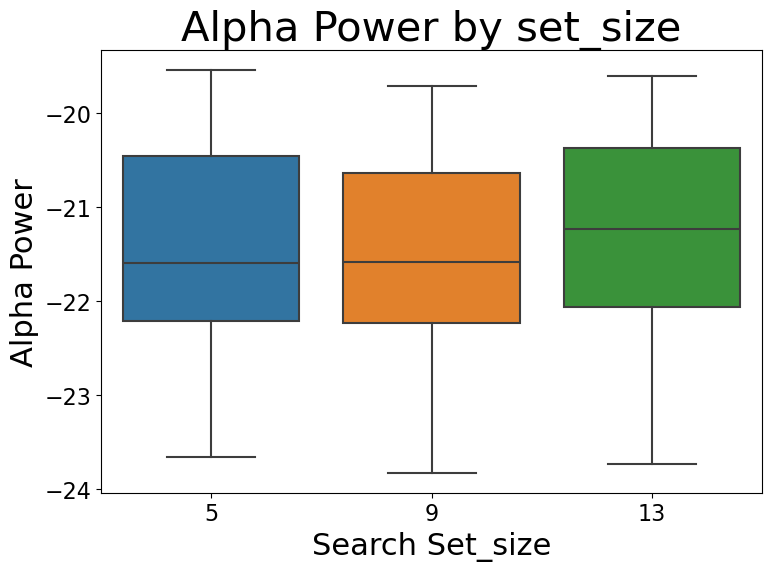

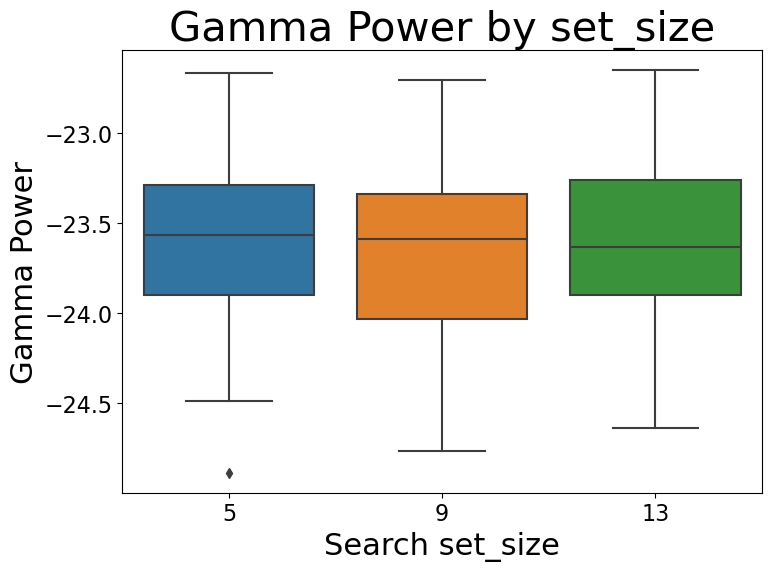

In [266]:
# ALPHA
plt.figure(figsize=(8, 6))
sns.boxplot(data=vs_eeg, x='set_size', y='alpha_power')
plt.title('Alpha Power by set_size')
plt.ylabel('Alpha Power')
plt.xlabel('Search Set_size')
plt.tight_layout()
plt.show()

# GAMMA
plt.figure(figsize=(8, 6))
sns.boxplot(data=vs_eeg, x='set_size', y='gamma_power')
plt.title('Gamma Power by set_size')
plt.ylabel('Gamma Power')
plt.xlabel('Search set_size')
plt.tight_layout()
plt.show()

In [267]:
grouped_alpha = [group['alpha_power'].dropna() for name, group in vs_eeg.groupby('set_size')]
grouped_gamma = [group['gamma_power'].dropna() for name, group in vs_eeg.groupby('set_size')]

# One-way ANOVA for alpha
f_alpha, p_alpha = stats.f_oneway(*grouped_alpha)
print(f"Alpha Power ANOVA: F = {f_alpha:.3f}, p = {p_alpha:.4f}")

# One-way ANOVA for gamma
f_gamma, p_gamma = stats.f_oneway(*grouped_gamma)
print(f"Gamma Power ANOVA: F = {f_gamma:.3f}, p = {p_gamma:.4f}")

Alpha Power ANOVA: F = 0.436, p = 0.6475
Gamma Power ANOVA: F = 0.348, p = 0.7069


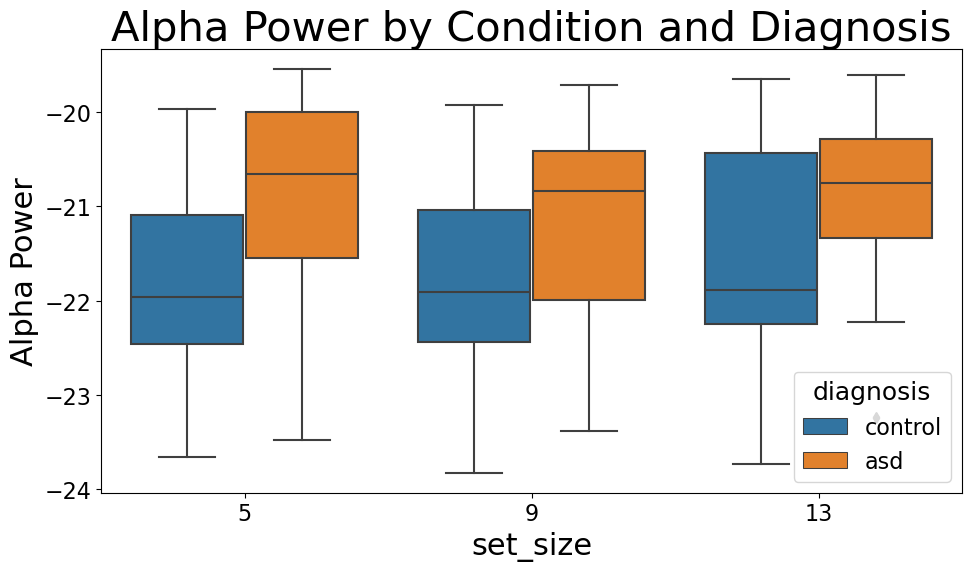

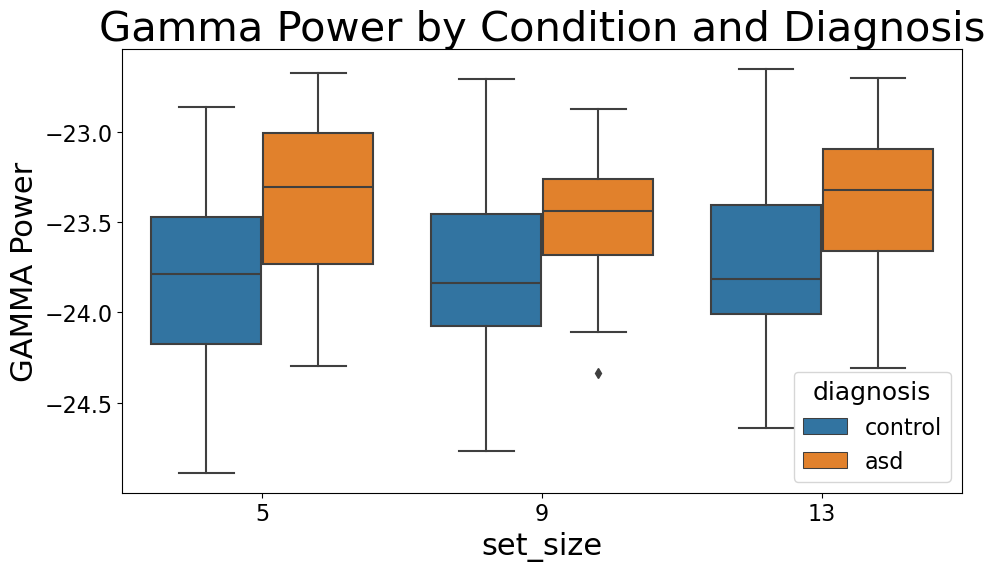

In [268]:
#Alpha
plt.figure(figsize=(10, 6))
sns.boxplot(data=vs_eeg, x='set_size', y='alpha_power', hue='diagnosis')
plt.title('Alpha Power by Condition and Diagnosis')
plt.ylabel('Alpha Power')
plt.xlabel('set_size')
plt.tight_layout()
plt.show()

#Gamma
plt.figure(figsize=(10, 6))
sns.boxplot(data=vs_eeg, x='set_size', y='gamma_power', hue='diagnosis')
plt.title('Gamma Power by Condition and Diagnosis')
plt.ylabel('GAMMA Power')
plt.xlabel('set_size')
plt.tight_layout()
plt.show()

In [269]:
pg.normality(data=vs_eeg, dv='alpha_power', group='diagnosis')

,W,pval,normal
diagnosis,,,
control,0.948211,0.002727,False
asd,0.922790,0.000651,False


In [270]:
pg.sphericity(data=vs_eeg, dv='alpha_power', subject='subject', within='set_size', method='mauchly')

SpherResults(spher=True, W=0.981751085096252, chi2=0.7182817300326395, dof=2, pval=0.6982759817657525)

In [271]:
pg.homoscedasticity(data=vs_eeg, dv='alpha_power', group='diagnosis', method='levene')

,W,pval,equal_var
levene,0.111858,0.738533,True


In [274]:
gamma_anova = pg.mixed_anova(
    dv='gamma_power',
    within='set_size',
    between='diagnosis',
    subject='subject',
    data=vs_eeg
).round(4)
gamma_anova

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,diagnosis,3.6250,1,39,3.6250,6.8730,0.0124,0.1498,NaN
1,set_size,0.0080,2,78,0.0040,0.3534,0.7034,0.0090,0.9751
2,Interaction,0.0109,2,78,0.0055,0.4811,0.6199,0.0122,NaN


In [275]:
gamma_anova = pg.mixed_anova(
    dv='P3b_amp',
    within='set_size',
    between='diagnosis',
    subject='subject',
    data=vs_eeg
).round(4)
gamma_anova

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,diagnosis,6.4285,1,39,6.4285,9.8900,0.0032,0.2023,NaN
1,set_size,0.3706,2,78,0.1853,2.7782,0.0683,0.0665,0.9224
2,Interaction,0.0280,2,78,0.0140,0.2100,0.8110,0.0054,NaN


In [279]:
post_hocs = pg.pairwise_tests(dv='alpha_power', within='set_size',
                               subject='subject', between = 'diagnosis', padjust='fdr_bh', data=vs_eeg).round(5)
post_hocs

,Contrast,set_size,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,set_size,-,5,9,True,True,-0.69314,40.00000,two-sided,0.49222,0.64835,fdr_bh,0.211,-0.01929
1,set_size,-,5,13,True,True,-1.05773,40.00000,two-sided,0.29652,0.64835,fdr_bh,0.284,-0.03143
2,set_size,-,9,13,True,True,-0.45951,40.00000,two-sided,0.64835,0.64835,fdr_bh,0.186,-0.01237
3,diagnosis,-,asd,control,False,True,2.20715,30.74056,two-sided,0.03490,NaN,NaN,2.018,0.70679
4,set_size * diagnosis,5,asd,control,False,True,2.43091,29.33760,two-sided,0.02140,0.04892,fdr_bh,2.959,0.78672
5,set_size * diagnosis,9,asd,control,False,True,2.04834,31.55772,two-sided,0.04892,0.04892,fdr_bh,1.568,0.65193
6,set_size * diagnosis,13,asd,control,False,True,2.10392,31.74483,two-sided,0.04340,0.04892,fdr_bh,1.71,0.66868


In [280]:
post_hocs = pg.pairwise_tests(dv='alpha_power', within='set_size',
                               subject='subject', between = 'diagnosis', padjust='fdr_bh', data=vs_eeg).round(5)
post_hocs

,Contrast,set_size,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,set_size,-,5,9,True,True,-0.69314,40.00000,two-sided,0.49222,0.64835,fdr_bh,0.211,-0.01929
1,set_size,-,5,13,True,True,-1.05773,40.00000,two-sided,0.29652,0.64835,fdr_bh,0.284,-0.03143
2,set_size,-,9,13,True,True,-0.45951,40.00000,two-sided,0.64835,0.64835,fdr_bh,0.186,-0.01237
3,diagnosis,-,asd,control,False,True,2.20715,30.74056,two-sided,0.03490,NaN,NaN,2.018,0.70679
4,set_size * diagnosis,5,asd,control,False,True,2.43091,29.33760,two-sided,0.02140,0.04892,fdr_bh,2.959,0.78672
5,set_size * diagnosis,9,asd,control,False,True,2.04834,31.55772,two-sided,0.04892,0.04892,fdr_bh,1.568,0.65193
6,set_size * diagnosis,13,asd,control,False,True,2.10392,31.74483,two-sided,0.04340,0.04892,fdr_bh,1.71,0.66868


In [281]:
post_hocs = pg.pairwise_tests(dv='P3b_amp', within='set_size',
                               subject='subject', between = 'diagnosis', padjust='fdr_bh', data=vs_eeg).round(5)
post_hocs

,Contrast,set_size,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,set_size,-,5,9,True,True,-0.30072,40.00000,two-sided,0.76519,0.76519,fdr_bh,0.176,-0.03322
1,set_size,-,5,13,True,True,2.10286,40.00000,two-sided,0.04182,0.06273,fdr_bh,1.223,0.20354
2,set_size,-,9,13,True,True,2.29268,40.00000,two-sided,0.02720,0.06273,fdr_bh,1.74,0.21435
3,diagnosis,-,asd,control,False,True,2.97092,27.19008,two-sided,0.00614,NaN,NaN,8.413,0.97762
4,set_size * diagnosis,5,asd,control,False,True,3.23214,25.69195,two-sided,0.00336,0.01008,fdr_bh,14.746,1.07664
5,set_size * diagnosis,9,asd,control,False,True,2.52547,34.27142,two-sided,0.01634,0.01634,fdr_bh,3.511,0.78724
6,set_size * diagnosis,13,asd,control,False,True,2.58904,25.67237,two-sided,0.01564,0.01634,fdr_bh,3.95,0.86256


In [282]:
post_hocs = pg.pairwise_tests(dv='N1_amp', within='set_size',
                               subject='subject', between = 'diagnosis', padjust='fdr_bh', data=vs_eeg).round(5)
post_hocs

,Contrast,set_size,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,set_size,-,5,9,True,True,0.61979,40.00000,two-sided,0.53891,0.64895,fdr_bh,0.202,0.07725
1,set_size,-,5,13,True,True,1.20804,40.00000,two-sided,0.23413,0.64895,fdr_bh,0.332,0.16410
2,set_size,-,9,13,True,True,0.45867,40.00000,two-sided,0.64895,0.64895,fdr_bh,0.186,0.07049
3,diagnosis,-,asd,control,False,True,1.24689,27.69165,two-sided,0.22288,NaN,NaN,0.571,0.40868
4,set_size * diagnosis,5,asd,control,False,True,2.38562,29.68933,two-sided,0.02364,0.07091,fdr_bh,2.732,0.77000
5,set_size * diagnosis,9,asd,control,False,True,0.72365,27.85791,two-sided,0.47531,0.71297,fdr_bh,0.381,0.23688
6,set_size * diagnosis,13,asd,control,False,True,0.27989,34.21614,two-sided,0.78125,0.78125,fdr_bh,0.319,0.08729


In [288]:
# Test the effects of group and condition on rt while accoutning for sex, age and site

# Create mixed effects model
model_formula = "N1_amp ~ C(diagnosis, Treatment(reference = 'control'))  * set_size + eeg_age + eeg_sex" #no_interaction

# Fit the model
model = smf.mixedlm(model_formula, vs_eeg, groups=vs_eeg["subject"],re_formula="~1").fit()

# Print the summary
model_summary = model.summary()
model_summary

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                   Mixed Linear Model Regression Results
===========================================================================================================
Model:                              MixedLM                  Dependent Variable:                  N1_amp   
No. Observations:                   144                      Method:                              REML     
No. Groups:                         53                       Scale:                               0.1747   
Min. group size:                    1                        Log-Likelihood:                      -123.5540
Max. group size:                    3                        Converged:                           Yes      
Mean group size:                    2.7                                                                    
-----------------------------------------------------------------------------------------------------------
                                                              Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                                    -13.190    0.338 -39.006 0.000 -13.853 -12.527
C(diagnosis, Treatment(reference='control'))[T.asd]            0.819    0.266   3.078 0.002   0.297   1.340
set_size                                                       0.018    0.015   1.259 0.208  -0.010   0.047
C(diagnosis, Treatment(reference='control'))[T.asd]:set_size  -0.049    0.022  -2.243 0.025  -0.091  -0.006
eeg_age                                                        0.006    0.005   1.040 0.298  -0.005   0.016
eeg_sex                                                        0.189    0.136   1.386 0.166  -0.078   0.455
Group Var                                                      0.162    0.135                              
===========================================================================================================

"""

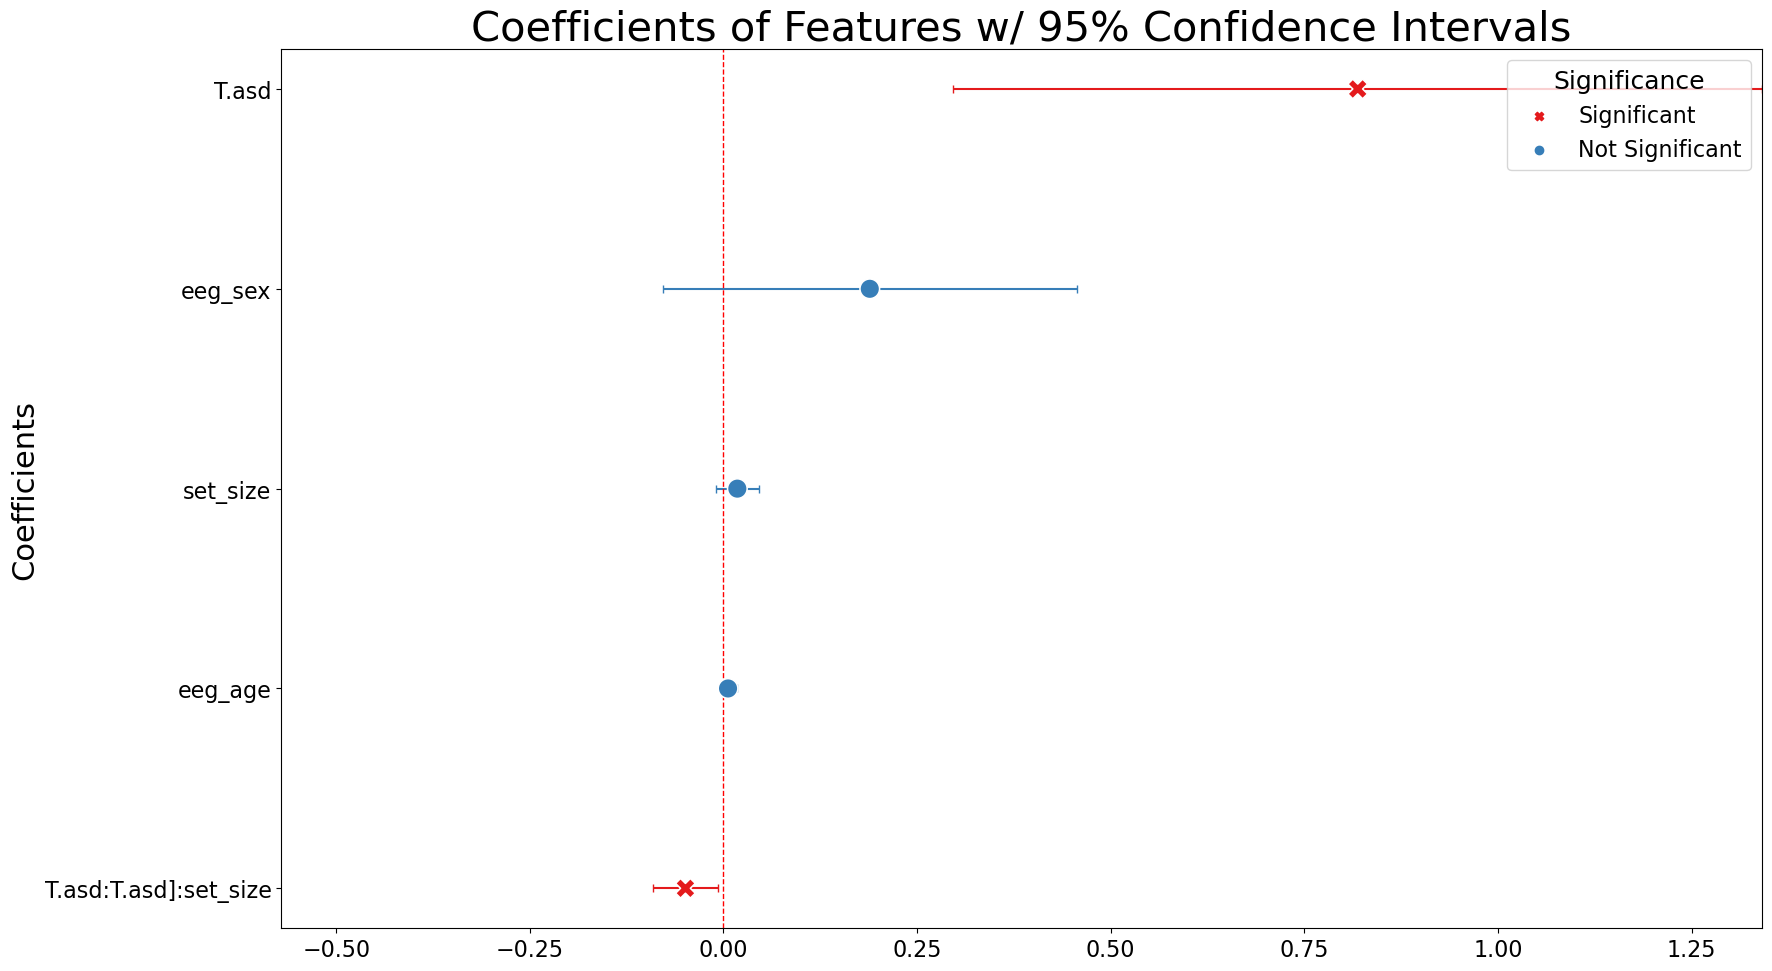

In [289]:
plt.rcParams.update({
    'font.size': 16,       # Base font size for ticks and text
    'axes.titlesize': 30,  # Title font
    'axes.labelsize': 22,  # Axis label font
    'xtick.labelsize': 16, # X-tick font
    'ytick.labelsize': 16, # Y-tick font
    'legend.fontsize': 16, # Legend font
    'legend.title_fontsize': 18  # Legend title font
})
coefplot_gap(model, multiple_models=False, fig_name='Simple Linear')
#nothing matters other than conditions (Faster 13 or 9)

In [290]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
model_comparison = {}
models_comp= {"original": "P3b_amp ~ C(diagnosis, Treatment(reference = 'control'))  * set_size", 
                "no_interaction":  "P3b_amp ~ C(diagnosis, Treatment(reference = 'control'))  + set_size"
}
coeff_dfs = []
model_comparisons_list = []
model_coefficients = []

for model_name, model_formula in models_comp.items():

    model1 = smf.mixedlm(model_formula, vs_eeg, groups=vs_eeg["subject"], re_formula="1").fit( reml=False)
    # Compare models
    coeff_dfs = []

    # Print the model
    print(model_name,model1.summary())

    #****** IF YOU WANT TO COMPARE MANY MODELS models = [model, model2, model3, model4, model5]
    models = [model1]

    log_likelihoods = [model.llf for model in models]
    aic = [model.aic for model in models]
    bic = [model.bic for model in models]
    converged = [model.converged for model in models]
    # Create dictionary with model names
    model_names = ["Mix Rand-int"]

    model_comparison = pd.DataFrame({"log_likelihood": log_likelihoods, "aic": aic, "bic": bic, "converged":converged }, index=model_names)
    # Collect homoscedasticity test results
    hom_test_results = []


    for model in models:
        hom_test_df = check_homoscedasticity(model, vs_eeg, show_text=False, co_vars=["age", "outcome", "sex", "site"])
        hom_test_results.append(hom_test_df.iloc[0])  # Assuming results are in a single row

        coeff_df = stage_model(model)
        coeff_dfs.append(coeff_df)


    # Convert list of series to a DataFrame
    hom_test_df_combined = pd.DataFrame(hom_test_results, index=model_comparison.index)

    # Merge with model comparison DataFrame
    model_comparison = pd.concat([model_comparison, hom_test_df_combined], axis=1)
    print(model_comparison)

    # Print model comparison results


   
    # Create df with all coefficients
    all_coefs = pd.concat(coeff_dfs, keys=model_names).reset_index()

    all_coefs["model_name"] = model_name
    all_coefs["model"] = model_name
    # Append all coeffts
    model_coefficients.append(all_coefs)
    model_comparisons_list.append(model_comparison)
# Create a df with all model comparisons
model_comparisons_df = pd.concat(model_comparisons_list, keys=models_comp.keys()).reset_index()
model_coefficients_df = pd.concat(model_coefficients)


#coefplot_gap(model_coefficients_df, multiple_models=True, fig_name="all_models")


# Drop unwanted columns
model_coefficients_df.drop(columns=["level_1","model_name"], inplace=True)
model_coefficients_df.rename(columns={"level_0": "model"}, inplace=True)
model_comparisons_df.drop(columns=["level_1"], inplace=True)
model_comparisons_df.rename(columns={"level_0": "model"}, inplace=True)

original                                    Mixed Linear Model Regression Results
Model:                               MixedLM                  Dependent Variable:                  P3b_amp 
No. Observations:                    144                      Method:                              ML      
No. Groups:                          53                       Scale:                               0.0619  
Min. group size:                     1                        Log-Likelihood:                      -73.0251
Max. group size:                     3                        Converged:                           Yes     
Mean group size:                     2.7                                                                   
-----------------------------------------------------------------------------------------------------------
                                                              Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
------------------------------------------------------

/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_42522/1244587587.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  levene = stats.levene(*[group_residuals for name, group_residuals in residuals.groupby(groups)])


Homoscedasticiyy checked
              log_likelihood         aic         bic  converged  \
Mix Rand-int      -73.562609  157.125217  171.974284       True   

              levene_test_all  white_test  bartlett_test  shapiro_test  \
Mix Rand-int         0.064893     0.29206   4.866241e-27      0.017737   

              multicollinearity     site  
Mix Rand-int           1.000909  0.05192  


/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_42522/1244587587.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  levene = stats.levene(*[group_residuals for name, group_residuals in residuals.groupby(groups)])


/var/folders/l2/gldr348j5ngb9kyqkcy1nswh0000gn/T/ipykernel_42522/2390626922.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="log_likelihood", y="model", data=model_comparisons_df, ax=ax[0, 0], palette="viridis", ci=None)


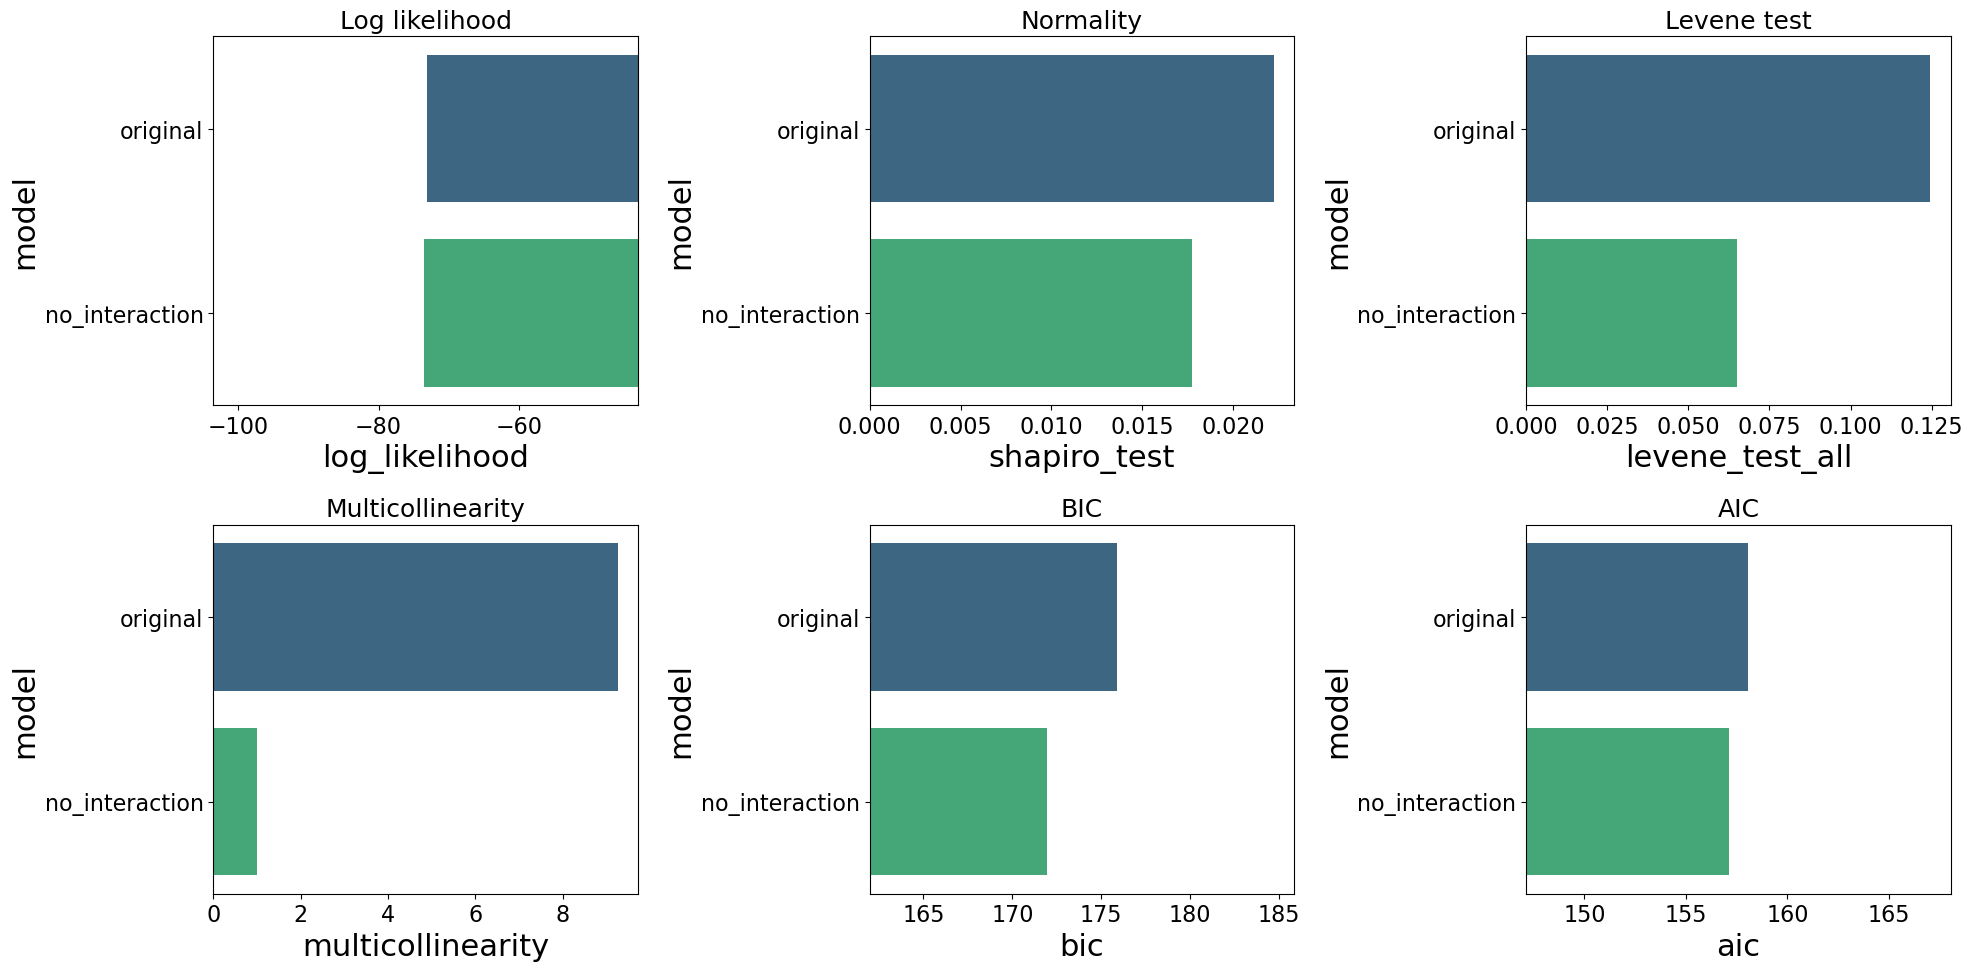

In [291]:
# Plot the different models and sort them by log likelihood

# Megerge all stages

model_comparisons_df["stage"]= "Standard"
model_comparisons_df_stages = model_comparisons_df.copy()

model_comparisons_df_stages = model_comparisons_df_stages.sort_values(by="log_likelihood", ascending=False)

# Plot the different models and sort them by log likelihood

model_comparisons_df = model_comparisons_df.sort_values(by="log_likelihood", ascending=False)

# Plot
fig, ax = plt.subplots(2, 3, figsize=(20, 10))

# Plot log likelihood
sns.barplot(x="log_likelihood", y="model", data=model_comparisons_df, ax=ax[0, 0], palette="viridis", ci=None)

# Calculate min and max of log_likelihood
log_likelihood_min = model_comparisons_df["log_likelihood"].min() - 30
log_likelihood_max = model_comparisons_df["log_likelihood"].max() + 30

# Set x-axis limits for ax[0, 0]
ax[0, 0].set_xlim(log_likelihood_min, log_likelihood_max)

# Plot Shapiro test
sns.barplot(x="shapiro_test", y="model", data=model_comparisons_df, ax=ax[0, 1], palette="viridis")

# Plot White test
sns.barplot(x="levene_test_all", y="model", data=model_comparisons_df, ax=ax[0, 2], palette="viridis")

# Plot Multicollinearity
sns.barplot(x="multicollinearity", y="model", data=model_comparisons_df, ax=ax[1, 0], palette="viridis")

# Plot BIC
sns.barplot(x="bic", y="model", data=model_comparisons_df, ax=ax[1, 1], palette="viridis")

# Calculate min and max of BIC
bic_min = model_comparisons_df["bic"].min() - 10
bic_max = model_comparisons_df["bic"].max() + 10

# Set x-axis limits for ax[1, 1]
ax[1, 1].set_xlim(bic_min, bic_max)


# Plot AIC
sns.barplot(x="aic", y="model", data=model_comparisons_df, ax=ax[1, 2], palette="viridis")

# Calculate min and max of AIC
aic_min = model_comparisons_df["aic"].min() - 10
aic_max = model_comparisons_df["aic"].max() + 10

# Set x-axis limits for ax[1, 2]
ax[1, 2].set_xlim(aic_min, aic_max)

# Add titles
ax[0, 0].set_title("Log likelihood", fontsize=18)
ax[0, 1].set_title("Normality", fontsize=18)
ax[0, 2].set_title("Levene test", fontsize=18)
ax[1, 0].set_title("Multicollinearity", fontsize=18)
ax[1, 1].set_title("BIC", fontsize=18)
ax[1, 2].set_title("AIC", fontsize=18)

# Change x-axis limits for the log likelihood plot
# ax[0, 0].set_xlim(1330, 1405)

plt.tight_layout()
plt.show()

In [ ]:
#mann_witney (diagnosis vs control)
#freidman if plots dont work and really 

In [ ]:
#add a column with the actual diagnosis (asd vs adhd vs control)